# Hopenhayn Firm Dynamics Model: Value Function Iteration

This notebook solves the stationary equilibrium of the Hopenhayn, Neira and Singhania (2022) firm dynamics model using standard Value Function Iteration (VFI) on a Tauchen grid.

$$V(s) = \max\left\{0,\; \pi(s) + \beta \sum_{s'} P(s'|s)\, V(s')\right\}$$

Outputs CSVs used by the DL notebook as a reference solution.

## Importing packages

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import time

## Config for plotting

In [2]:
fontsize = 14
ticksize = 14
plt.rcParams.update({
    'font.family': 'serif',
    'figure.figsize': (6, 4),
    'figure.dpi': 80,
    'figure.edgecolor': 'k',
    'font.size': fontsize,
    'axes.labelsize': fontsize,
    'axes.titlesize': fontsize,
    'xtick.labelsize': ticksize,
    'ytick.labelsize': ticksize,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

COLOR_VFI = '#D55E00'

## Model parameters

In [3]:
beta   = 1.0 / 1.04                   # Discount factor
alpha  = 0.64                          # Labor share
g      = 0.01                          # Trend in the labor force
pstar  = 1.0                           # Equilibrium output price
mstar  = 100.0                         # Mass of entrants

rho    = 0.984150757243253             # AR(1) persistence
sigmaF = 0.245520815536363             # Std dev of AR(1) innovations
muF    = -2.431373086987380            # Long-run AR(1) mean
cf     = 2.298950284374937             # Fixed operating cost

muG    = -4.344376541584754            # Mean of startup distribution
sigmaG = 1.331137767741511             # Std dev of startup distribution

## Tauchen discretization of the AR(1) process

In [4]:
def tauchen(mu, rho_val, sig, N, m=5):
    sigma_uncond = np.sqrt(sig**2 / (1 - rho_val**2))
    svec = np.linspace(mu - m * sigma_uncond, mu + m * sigma_uncond, N)
    step = svec[1] - svec[0]
    Pi = np.zeros((N, N))
    for j in range(N):
        for k in range(N):
            if k == 0:
                Pi[j, k] = norm.cdf((svec[0] - (1 - rho_val) * mu - rho_val * svec[j] + step / 2) / sig)
            elif k == N - 1:
                Pi[j, k] = 1.0 - norm.cdf((svec[-1] - (1 - rho_val) * mu - rho_val * svec[j] - step / 2) / sig)
            else:
                Pi[j, k] = (norm.cdf((svec[k] - (1 - rho_val) * mu - rho_val * svec[j] + step / 2) / sig)
                          - norm.cdf((svec[k] - (1 - rho_val) * mu - rho_val * svec[j] - step / 2) / sig))
    return svec, Pi

In [5]:
ns = 100
tol = 1e-8

svec, Pi = tauchen(muF, rho, sigmaF, ns)
F = Pi.T  # Transpose so columns sum to one (same as MATLAB)

# Startup productivity distribution
step = svec[1] - svec[0]
G = norm.cdf(svec + step / 2, muG, sigmaG)
G[1:-1] = G[1:-1] - G[:-2]
G[-1] = 1.0 - np.sum(G[:-1])

print(f"Grid: {ns} points, s in [{svec[0]:.2f}, {svec[-1]:.2f}]")

Grid: 100 points, s in [-9.35, 4.49]


## Profit and labor demand

$$\pi(s) = \left(p \cdot e^s \cdot \alpha^\alpha\right)^{1/(1-\alpha)} (1-\alpha) - c_f \qquad n^*(s) = \left(p \cdot e^s \cdot \alpha\right)^{1/(1-\alpha)}$$

In [6]:
def profit(s, p):
    return (p * np.exp(s) * alpha**alpha) ** (1.0 / (1.0 - alpha)) * (1.0 - alpha) - cf

def n_star(s, p):
    return (p * np.exp(s) * alpha) ** (1.0 / (1.0 - alpha))

## Value Function Iteration

$$V(s) = \max\left\{0,\; \pi(s) + \beta \cdot E[V(s') | s]\right\}$$

In [7]:
def vfi_solve(svec, F, p, tol=1e-8, maxiter=5000):
    N = len(svec)
    v = np.zeros(N)
    Tv = v + 1.0
    it = 0
    pi = profit(svec, p)

    t0 = time.time()
    while np.max(np.abs(Tv - v)) > tol and it <= maxiter:
        v = Tv.copy()
        Ev = F.T @ v
        Tv = np.maximum(0.0, pi + beta * Ev)
        it += 1
    elapsed = time.time() - t0

    print(f"VFI converged in {it} iterations (residual = {np.max(np.abs(Tv - v)):.2e})")
    print(f"VFI iteration time: {elapsed:.4f} seconds")
    return Tv, elapsed

In [8]:
V_vfi, vfi_time = vfi_solve(svec, F, pstar, tol=tol)

VFI converged in 294 iterations (residual = 9.26e-09)
VFI iteration time: 0.0014 seconds


## Stationary equilibrium

In [9]:
# Exit threshold
active = np.where(V_vfi > 0)[0]
sstar_ind = active[0]
sstar = svec[sstar_ind]

# Entry cost (free-entry condition)
ce = np.sum(V_vfi * G)

# Startup distribution truncated at exit threshold
Gnew = G.copy()
Gnew[:sstar_ind] = 0.0

# Transition matrix truncated at exit
Fnew = F.copy()
Fnew[:, :sstar_ind] = 0.0

# Stationary distribution: mu = (I - Fnew/(1+g))^{-1} * (mstar * Gnew)
I = np.eye(ns)
mustar = np.linalg.solve(I - Fnew / (1 + g), mstar * Gnew)
mustar[:sstar_ind] = 0.0

# Employment
nstar = n_star(svec, pstar)
nstar_adj = nstar + cf
nstar_adj[:sstar_ind] = 0.0

N = np.sum(nstar_adj * mustar) + mstar * ce
avg_stsize = np.sum(nstar_adj * Gnew / np.sum(Gnew))
avg_fsize  = np.sum(nstar_adj * mustar) / np.sum(mustar)
startup_rate = mstar * np.sum(Gnew) / (np.sum(mustar) / (1 + g))

print("=" * 50)
print("Stationary equilibrium results:")
print(f"  Exit threshold:    s* = {sstar:.4f}  (index {sstar_ind})")
print(f"  Entry cost:        ce = {ce:.4f}")
print(f"  Total employment:  N  = {N:.2f}")
print(f"  Avg startup size:  {avg_stsize:.4f}")
print(f"  Avg firm size:     {avg_fsize:.4f}")
print(f"  Startup rate:      {startup_rate:.4f}")
print(f"  VFI time:          {vfi_time:.4f} s")
print("=" * 50)

Stationary equilibrium results:
  Exit threshold:    s* = 0.0160  (index 67)
  Entry cost:        ce = 0.0149
  Total employment:  N  = 12.55
  Avg startup size:  3.9758
  Avg firm size:     18.8447
  Startup rate:      0.1091
  VFI time:          0.0014 s


## Plots

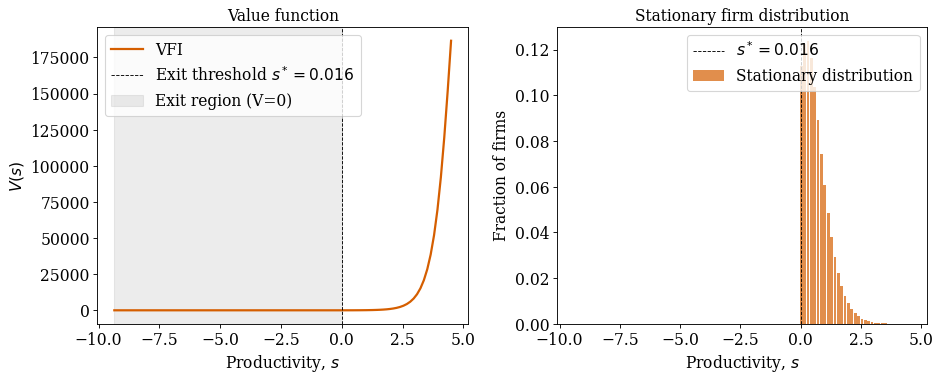

Saved value_function_VFI.pdf/png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Left panel: Value function ----
ax = axes[0]
ax.plot(svec, V_vfi, color=COLOR_VFI, linewidth=2, label='VFI')
ax.axvline(x=sstar, color='k', linestyle='--', linewidth=0.8,
           label=rf'Exit threshold $s^*={sstar:.3f}$')
ax.axvspan(svec[0], sstar, color='gray', alpha=0.15, label='Exit region (V=0)')
ax.set_xlabel(r'Productivity, $s$')
ax.set_ylabel(r'$V(s)$')
ax.set_title('Value function')
ax.legend(loc='upper left')

# ---- Right panel: Stationary firm distribution ----
ax = axes[1]
mu_normalized = mustar / np.sum(mustar)
ax.bar(svec, mu_normalized, width=step * 0.8, color=COLOR_VFI, alpha=0.7,
       label='Stationary distribution')
ax.axvline(x=sstar, color='k', linestyle='--', linewidth=0.8,
           label=rf'$s^*={sstar:.3f}$')
ax.set_xlabel(r'Productivity, $s$')
ax.set_ylabel('Fraction of firms')
ax.set_title('Stationary firm distribution')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('output_figures/value_function_VFI.pdf')
plt.savefig('output_figures/value_function_VFI.png', dpi=300)
plt.show()
print('Saved value_function_VFI.pdf/png')

## Export CSVs for DL notebook

In [11]:
np.savetxt('output_csv/v_VFI.csv',      V_vfi,  delimiter=',')
np.savetxt('output_csv/svec_VFI.csv',   svec,   delimiter=',')
np.savetxt('output_csv/nstar_VFI.csv',  nstar,  delimiter=',')
np.savetxt('output_csv/mustar_VFI.csv', mustar, delimiter=',')
print('Exported: v_VFI.csv, svec_VFI.csv, nstar_VFI.csv, mustar_VFI.csv')

Exported: v_VFI.csv, svec_VFI.csv, nstar_VFI.csv, mustar_VFI.csv
